### Round 1 barcode distribution across wells

In [16]:
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:

well_map = pd.read_csv("../references/well-map.tsv", sep="\t")
mapping = dict(well_map[['barcode', 'Well']].values)

glob_patterns = [
    "../well-counts/*PKR-432*",
    "../well-counts/*PKR-433*",
    "../well-counts/*PKR-434*",
    "../well-counts/*PKR-435*",
    "../well-counts/*PKR-436*"
]

all_files = []
for pattern in glob_patterns:
    all_files.extend(glob.glob(pattern))
    
df_list = []

for file in all_files:
    df = pd.read_csv(file, header=None, sep=r"\s+")
    df.columns = ["count", "barcode"]
    
    # Keep only barcodes from well map
    df = df[df["barcode"].isin(well_map["barcode"])]
    
    df['well'] = df["barcode"].map(mapping)
    
    # Force all wells to be present:
    wells_df = pd.DataFrame({'well': well_map['Well'], 'barcode': well_map['barcode']})
    df = pd.merge(wells_df, df, on=['well', 'barcode'], how='left')
    df["count"] = df["count"].fillna(0).astype(int)
    
    sample_name = file.split("/")[-1].replace(".counts.txt", "")
    df['sample'] = sample_name
    
    df_list.append(df)

final_df = pd.concat(df_list, ignore_index=True)

final_df = final_df.sort_values(["sample", "well"])

final_df.head()



['../well-counts/SS-CoPA-1909_L5_SS-PKR-432_2022-APRIL-R1-SET-OF-192_R2.counts.txt', '../well-counts/SS-CoPA-1914_L8_SS-PKR-432_2022-APRIL-R1-SET-OF-192_R2.counts.txt', '../well-counts/SS-CoPA-1909_L6_SS-PKR-432_2022-APRIL-R1-SET-OF-192_R2.counts.txt', '../well-counts/SS-CoPA-1574_L1_SS-PKR-432_2022-APRIL-R1-SET-OF-192_R2.counts.txt', '../well-counts/SS-CoPA-1574_L3_SS-PKR-432_2022-APRIL-R1-SET-OF-192_R2.counts.txt', '../well-counts/SS-CoPA-1588_L5_SS-PKR-432_2022-APRIL-R1-SET-OF-192_R2.counts.txt', '../well-counts/SS-CoPA-1588_L4_SS-PKR-432_2022-APRIL-R1-SET-OF-192_R2.counts.txt', '../well-counts/SS-CoPA-1574_L2_SS-PKR-432_2022-APRIL-R1-SET-OF-192_R2.counts.txt', '../well-counts/SS-CoPA-1915_L8_SS-PKR-433_2022-APRIL-R1-SET-OF-192_R2.counts.txt', '../well-counts/SS-CoPA-1575_L3_SS-PKR-433_2022-APRIL-R1-SET-OF-192_R2.counts.txt', '../well-counts/SS-CoPA-1910_L6_SS-PKR-433_2022-APRIL-R1-SET-OF-192_R2.counts.txt', '../well-counts/SS-CoPA-1589_L5_SS-PKR-433_2022-APRIL-R1-SET-OF-192_R2.coun

,well,barcode,count,sample
5376,Round1_01,AACGTGAT,79123,SS-CoPA-1534_L1_SS-PKR-434_2022-APRIL-R1-SET-O...
5377,Round1_02,AAACATCG,102859,SS-CoPA-1534_L1_SS-PKR-434_2022-APRIL-R1-SET-O...
5378,Round1_03,ATGCCTAA,125383,SS-CoPA-1534_L1_SS-PKR-434_2022-APRIL-R1-SET-O...
5379,Round1_04,AGTGGTCA,123160,SS-CoPA-1534_L1_SS-PKR-434_2022-APRIL-R1-SET-O...
5380,Round1_05,ACCACTGT,122575,SS-CoPA-1534_L1_SS-PKR-434_2022-APRIL-R1-SET-O...


In [35]:
#final_df["sample_pkr"] = final_df["sample"].str.split("_").str[2]
final_df

,well,barcode,count,sample,sample_pkr
5376,Round1_01,AACGTGAT,79123,SS-CoPA-1534_L1_SS-PKR-434_2022-APRIL-R1-SET-O...,SS-PKR-434
5377,Round1_02,AAACATCG,102859,SS-CoPA-1534_L1_SS-PKR-434_2022-APRIL-R1-SET-O...,SS-PKR-434
5378,Round1_03,ATGCCTAA,125383,SS-CoPA-1534_L1_SS-PKR-434_2022-APRIL-R1-SET-O...,SS-PKR-434
5379,Round1_04,AGTGGTCA,123160,SS-CoPA-1534_L1_SS-PKR-434_2022-APRIL-R1-SET-O...,SS-PKR-434
5380,Round1_05,ACCACTGT,122575,SS-CoPA-1534_L1_SS-PKR-434_2022-APRIL-R1-SET-O...,SS-PKR-434
...,...,...,...,...,...
9118,Round1_95,GATGAATC,1844960,SS-CoPA-1918_L8_SS-PKR-436_2022-APRIL-R1-SET-O...,SS-PKR-436
9119,Round1_96,GCCAAGAC,589782,SS-CoPA-1918_L8_SS-PKR-436_2022-APRIL-R1-SET-O...,SS-PKR-436
9120,Round1_97,CTACCAGT,591704,SS-CoPA-1918_L8_SS-PKR-436_2022-APRIL-R1-SET-O...,SS-PKR-436
9121,Round1_98,GTTGGAGC,1023512,SS-CoPA-1918_L8_SS-PKR-436_2022-APRIL-R1-SET-O...,SS-PKR-436


In [29]:
final_df.to_csv("../results/well-counts.txt", sep = "\t", index=False)

In [43]:
final_df['sample_id'] = final_df['sample'].str.extract(r'(SS-PKR-\d+)')

summary_df = final_df.groupby(['sample_id', 'well'], as_index=False)['count'].sum()
summary_df['plate_id'] = [ int(xx.split("_")[1]) for xx in summary_df['well']]
summary_df = summary_df.sort_values(['plate_id', 'well'])

summary_df

,sample_id,well,count,plate_id
0,SS-PKR-432,Round1_01,5639223,1
192,SS-PKR-433,Round1_01,3746910,1
384,SS-PKR-434,Round1_01,6848484,1
576,SS-PKR-435,Round1_01,5641460,1
768,SS-PKR-436,Round1_01,4744555,1
...,...,...,...,...
132,SS-PKR-432,Round1_404,3912366,404
324,SS-PKR-433,Round1_404,6783021,404
516,SS-PKR-434,Round1_404,3977964,404
708,SS-PKR-435,Round1_404,4154285,404


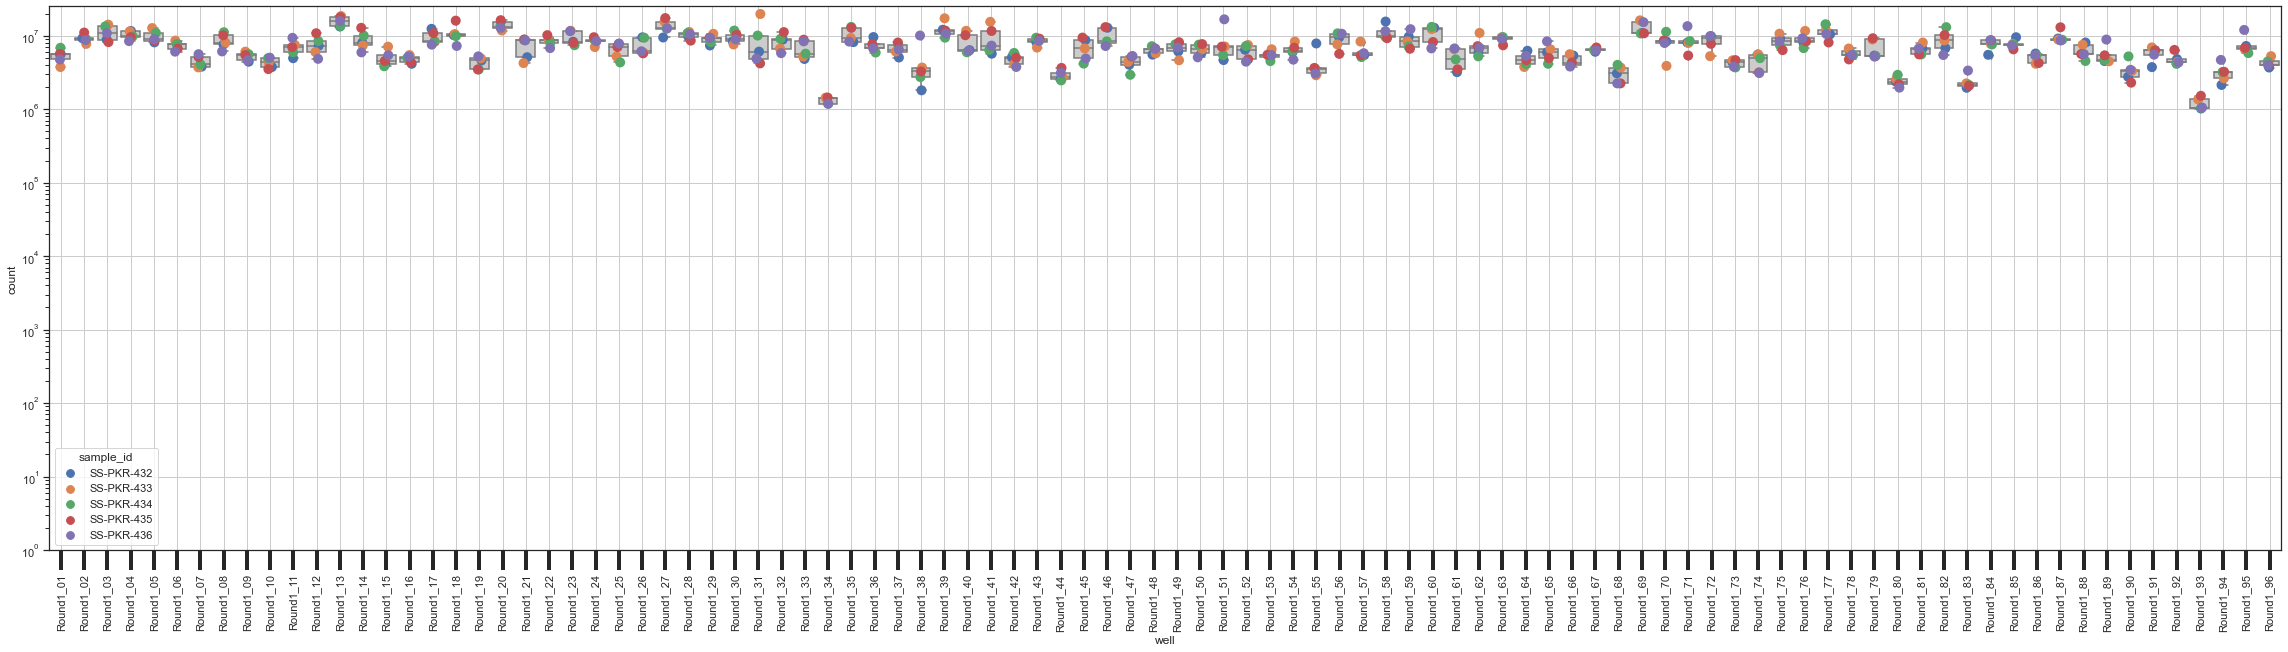

In [49]:
sns.set_context("paper", rc={"font.size":10,"axes.titlesize":10,"axes.labelsize":8})   

sns.set(rc={"figure.figsize":(40, 10)})
sns.set_style('white', {'axes.linewidth': 0.5})
plt.rcParams['xtick.major.size'] = 20
plt.rcParams['xtick.major.width'] = 4
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True

ax = sns.stripplot(data=summary_df[summary_df["plate_id"] <=96 ], x = "well", y = "count",
                   hue="sample_id", jitter=True, dodge=False, size = 10)

ax = sns.boxplot(data=summary_df[summary_df["plate_id"] <= 96], x = "well", y = "count", color="0.8")

plt.xticks(rotation=90)
plt.yscale("log")
plt.ylim(1,25000000)
plt.grid()
plt.show() 

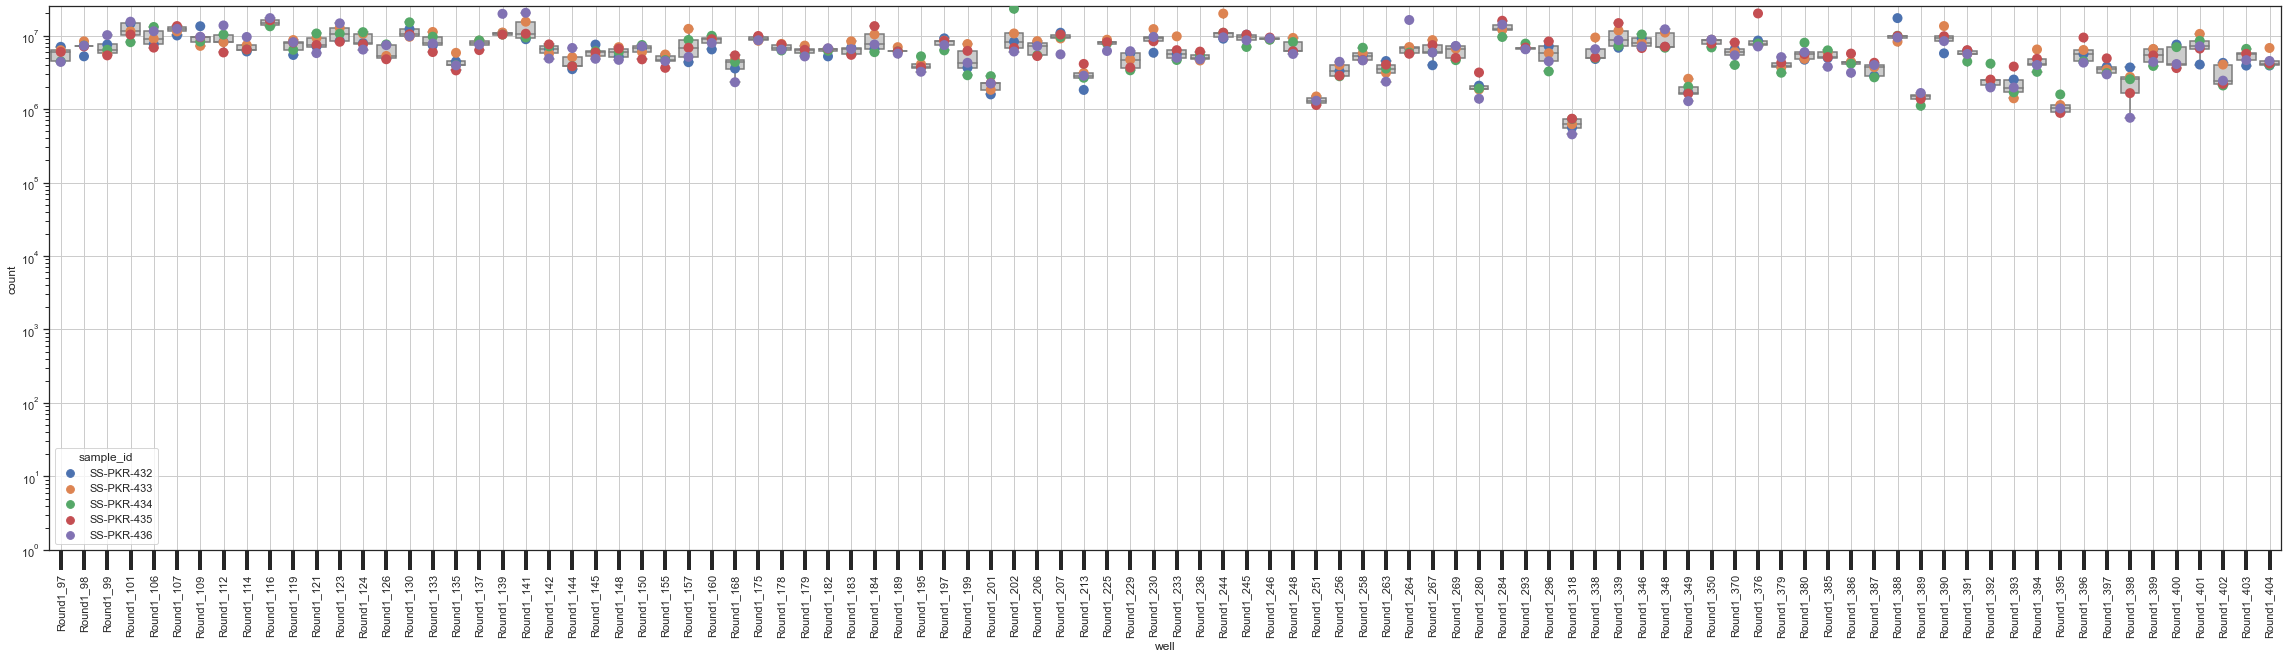

In [48]:
sns.set_context("paper", rc={"font.size":10,"axes.titlesize":10,"axes.labelsize":8})   

sns.set(rc={"figure.figsize":(40, 10)})
sns.set_style('white', {'axes.linewidth': 0.5})
plt.rcParams['xtick.major.size'] = 20
plt.rcParams['xtick.major.width'] = 4
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True

ax = sns.stripplot(data=summary_df[summary_df["plate_id"] > 96], x = "well", y = "count",
                   hue="sample_id", jitter=False, dodge=False, size = 10)

# Overlay the boxplot with a light color
ax = sns.boxplot(data=summary_df[summary_df["plate_id"] > 96], x = "well", y = "count", color="0.8")

plt.xticks(rotation=90)
plt.yscale("log")
plt.grid()
plt.ylim(1,25000000)
plt.show() 